# Exploratory Data Analysis: Palmer Penguins
Problem Statement: This analysis aims to investigate how physical measurements of each species of Palmer Penguins affect their overall population. Through this analysis, each species is investigated through numerous graphs, such as a box plot to showcase how each island accommodates to the different species. Different numerical measurements are then compared to see how each variable correlates and contrasts to provide different results. These numerical measurements are then compared within sixteen different graphs to provide a clearer picture of how different body measurements lead to certain species being allocated at specific islands. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("penguins_size.csv")
display(df.head())

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


We first display the first five rows of the dataset to begin the first stages of analysis.

In [3]:
rename_map = {
    'species': 'Species',
    'island': 'Island',
    'culmen_length_mm': 'Culmen Length (mm)',
    'culmen_depth_mm': 'Culmen Depth (mm)',
    'flipper_length_mm': 'Flipper Length (mm)',
    'body_mass_g': 'Body Mass (g)',
    'sex': 'Sex'
}
df = df.rename(columns=rename_map)

new_order = [
    'Island', 
    'Species', 
    'Sex', 
    'Culmen Length (mm)', 
    'Culmen Depth (mm)', 
    'Flipper Length (mm)', 
    'Body Mass (g)'
]
df = df[new_order]

display(df.head())

,Island,Species,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,Torgersen,Adelie,MALE,39.1,18.7,181.0,3750.0
1,Torgersen,Adelie,FEMALE,39.5,17.4,186.0,3800.0
2,Torgersen,Adelie,FEMALE,40.3,18.0,195.0,3250.0
3,Torgersen,Adelie,NaN,NaN,NaN,NaN,NaN
4,Torgersen,Adelie,FEMALE,36.7,19.3,193.0,3450.0


The columns are then renamed and reorganized, so that they are in the correct capitalization, and also so they are placed together accordingly to categorical vs numerical variables. 

In [4]:
df['Sex'] = df['Sex'].str.title()
display(df.head())

,Island,Species,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,Torgersen,Adelie,Male,39.1,18.7,181.0,3750.0
1,Torgersen,Adelie,Female,39.5,17.4,186.0,3800.0
2,Torgersen,Adelie,Female,40.3,18.0,195.0,3250.0
3,Torgersen,Adelie,NaN,NaN,NaN,NaN,NaN
4,Torgersen,Adelie,Female,36.7,19.3,193.0,3450.0


The variables under the "sex" column is formatted into its proper casing, removing the all-caps capitalization beforehand. 

In [5]:
print(df.isnull().sum())

Island                  0
Species                 0
Sex                    10
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
dtype: int64


This prints the dataset before the null values are cleaned.

In [6]:
df_cleaned = df.dropna().copy()
print(df_cleaned.isnull().sum())

Island                 0
Species                0
Sex                    0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
dtype: int64


After the null values are cleaned, the dataset is printed again (to show there are no longer any null values).

In [7]:
print(df_cleaned['Species'].value_counts())
print()
print(df_cleaned['Island'].value_counts())
print()
print(df_cleaned['Sex'].value_counts())

Species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

Island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

Sex
Male      168
Female    165
.           1
Name: count, dtype: int64


From the clean dataset, one final check is made to see whether all values within each column are correct. As seen over here, the "sex" column has one singular variable that does not align with the category, which is the full-stop. Through one final cleaning, it can be removed.

In [8]:
df_final = df_cleaned[df_cleaned['Sex'] != '.'].copy()
print(df_final['Sex'].value_counts())

Sex
Male      168
Female    165
Name: count, dtype: int64


The column for "sex" is finally fully clean. 

In [9]:
display(df_cleaned.sample(20, random_state=42).sort_values(by='Island'))
print(f"\nNumber of penguins to analyze: {df_cleaned.shape[0]}")

,Island,Species,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
282,Biscoe,Gentoo,Female,45.7,13.9,214.0,4400.0
317,Biscoe,Gentoo,Female,46.9,14.6,222.0,4875.0
63,Biscoe,Adelie,Male,41.1,18.2,192.0,4050.0
304,Biscoe,Gentoo,Female,44.9,13.8,212.0,4750.0
289,Biscoe,Gentoo,Male,50.7,15.0,223.0,5550.0
272,Biscoe,Gentoo,Female,45.1,14.4,210.0,4400.0
329,Biscoe,Gentoo,Male,48.1,15.1,209.0,5500.0
152,Dream,Chinstrap,Female,46.5,17.9,192.0,3500.0
138,Dream,Adelie,Female,37.0,16.5,185.0,3400.0
132,Dream,Adelie,Female,36.8,18.5,193.0,3500.0



Number of penguins to analyze: 334


Twenty random samples are displayed from the dataset, and now the islands are sorted in order (the rest of the columns following as such).

In [10]:
display(df_cleaned.describe())

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
count,334.000000,334.000000,334.000000,334.000000
mean,43.994311,17.160479,201.014970,4209.056886
std,5.460521,1.967909,14.022175,804.836129
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.575000,18.700000,213.000000,4793.750000
max,59.600000,21.500000,231.000000,6300.000000


This table shows the different measurements of all the numerical variables.

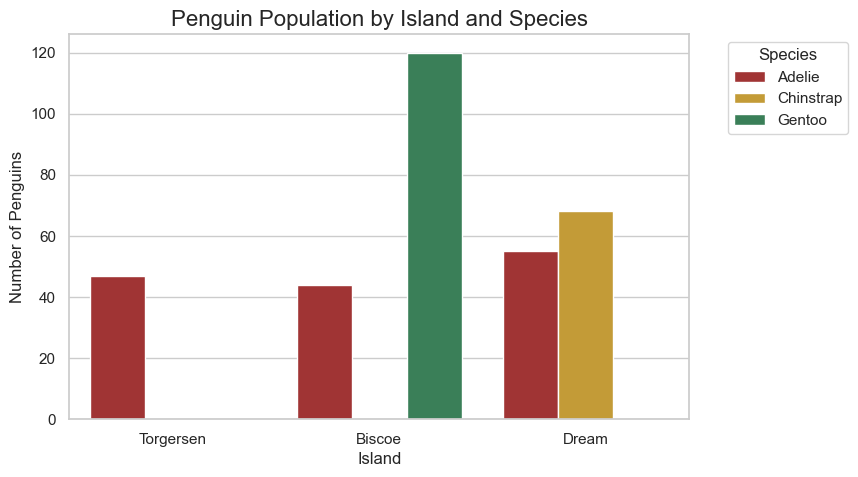

In [11]:
plt.figure(figsize=(8, 5))

species_colors = {
    'Adelie': 'firebrick',
    'Chinstrap': 'goldenrod',
    'Gentoo': 'seagreen'
}

sns.countplot(data=df_cleaned, x='Island', hue='Species', palette=species_colors)

plt.title('Penguin Population by Island and Species', fontsize=16)
plt.xlabel('Island', fontsize=12)
plt.ylabel('Number of Penguins', fontsize=12)

plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Through this bar chart, we can see that Adelie penguins are distributed almost evenly among all three islands, whereas the Gentoo population is only situated at Biscoe Island, and the Chinstrap Island situated only on Dream Island. Additionally, the amount of Gentoo Penguins on Biscoe is more than the amount of Chinstrap on Dream. Why is it that Adelie can adjust to all three islands, whereas the other two species are not able to? We can further analyze this problem by diving into the numerical variables in the dataset, comparing the different flipper measurements and body mass (in grams).

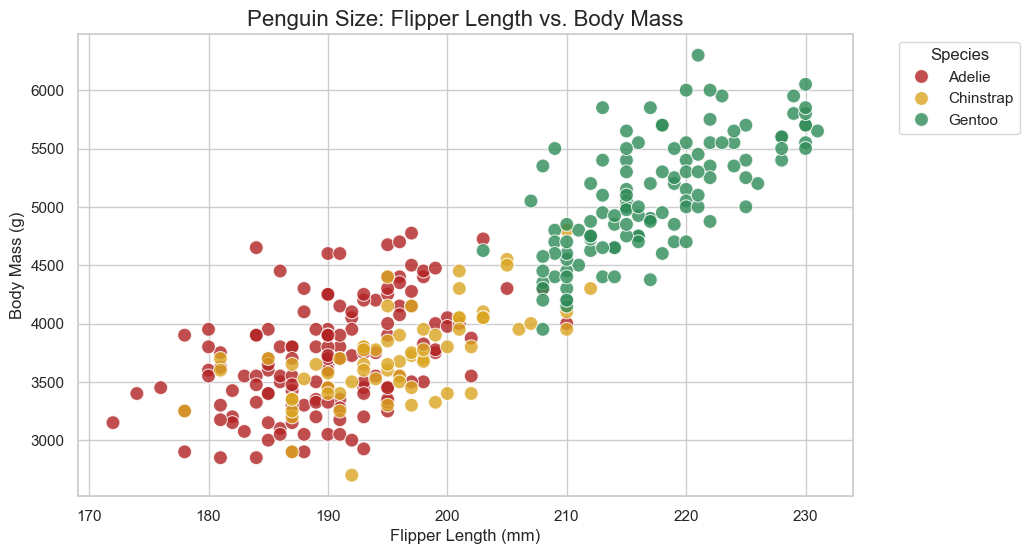

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_cleaned, x='Flipper Length (mm)', y='Body Mass (g)', hue='Species', s=100, alpha=0.8, palette=species_colors)

plt.title('Penguin Size: Flipper Length vs. Body Mass', fontsize=16)
plt.xlabel('Flipper Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)

plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

This scatterplot clearly illustrates that Gentoo penguins are bigger than the other two species, and we can analyze from there that Biscoe Island can accommodate to larger species (maybe through better resources, more food, or shelter that accodomates bigger species compared to the other two islands). To compare Adelie and Chinstrap penguins, we can't derive further from this scatterplot because their measurements in this graph almost correlate with each other. Because of that, we will then further analyze the Adelie and Chinstrap species through different graphs.

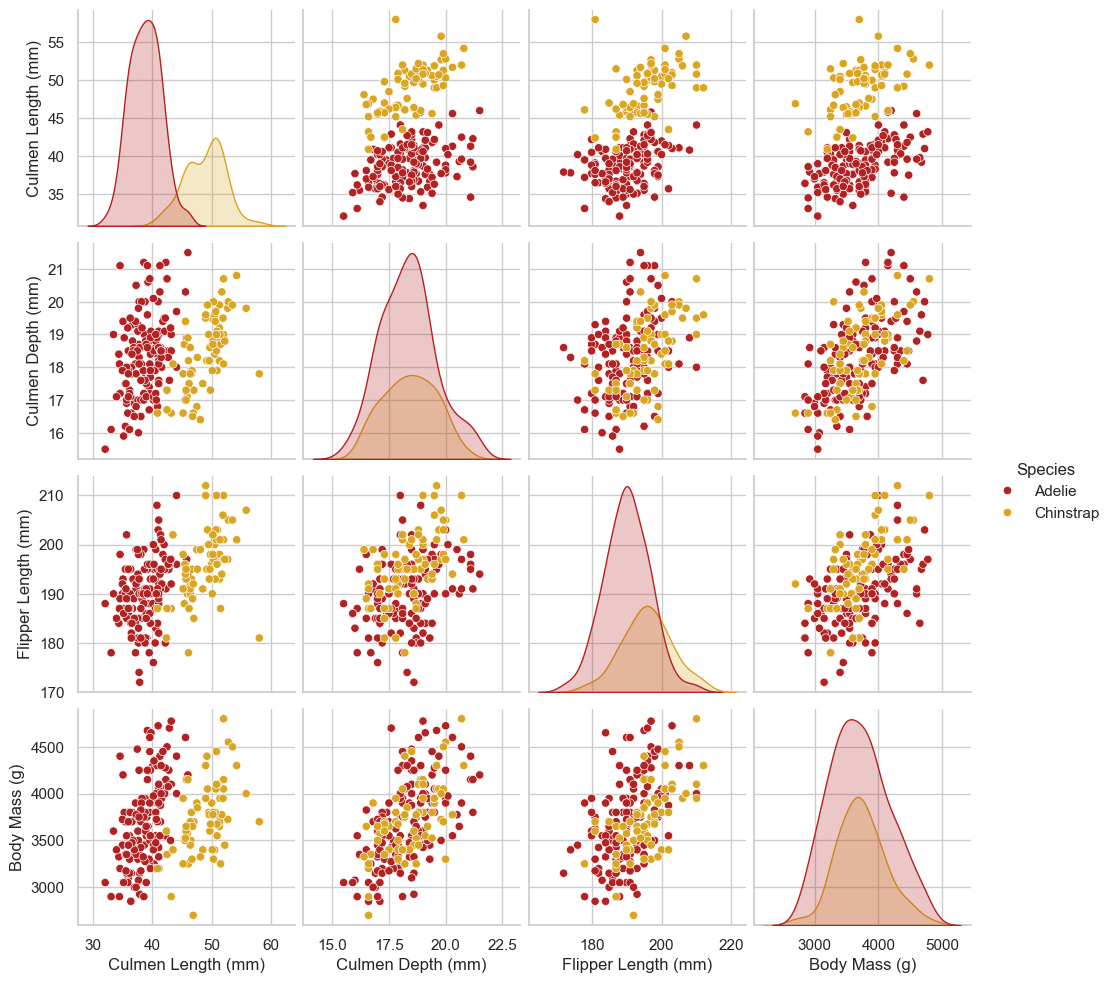

In [13]:
twins_df = df_cleaned[df_cleaned['Species'] != 'Gentoo']

sns.pairplot(twins_df, hue='Species', palette=species_colors)
plt.show()

Now that we have a clear picture of how Gentoo Penguins accommodate to Biscoe Island, we can now remove them from the equation regarding further analysis. We now compare the Adelie and Chinstrap species with sixteen graphs of different varieties. The KDE graphs  display that the measurements of the Adelie and Chinstrap species largely overlap, which means their differences can't be measured through generalization of size alone.

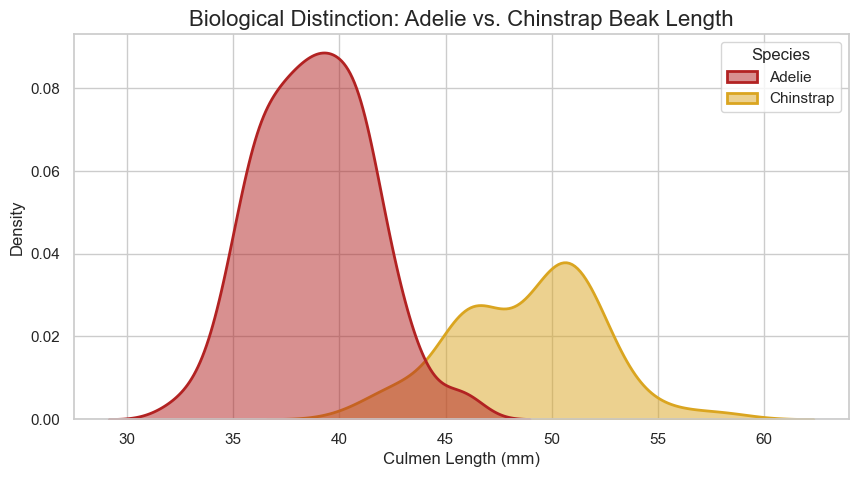

In [14]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=df_cleaned[df_cleaned['Species'] != 'Gentoo'], 
            x='Culmen Length (mm)', 
            hue='Species', 
            palette={'Adelie': 'firebrick', 'Chinstrap': 'goldenrod'}, 
            fill=True, 
            alpha=0.5, 
            linewidth=2)

plt.title('Biological Distinction: Adelie vs. Chinstrap Beak Length', fontsize=16)
plt.xlabel('Culmen Length (mm)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.show()

Through analyzing the culmen length, this KDE graph shows that Adelie penguins have smaller beaks compared the Chinstrap penguins.

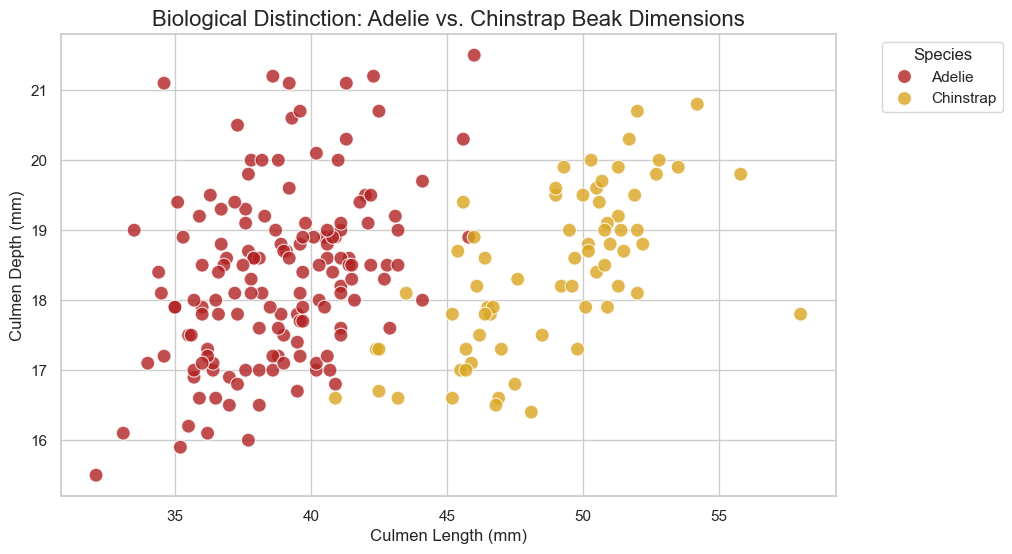

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_cleaned[df_cleaned['Species'] != 'Gentoo'], 
                x='Culmen Length (mm)', 
                y='Culmen Depth (mm)', 
                hue='Species', 
                palette={'Adelie': 'firebrick', 'Chinstrap': 'goldenrod'}, 
                s=100, alpha=0.8)

plt.title('Biological Distinction: Adelie vs. Chinstrap Beak Dimensions', fontsize=16)
plt.xlabel('Culmen Length (mm)', fontsize=12)
plt.ylabel('Culmen Depth (mm)', fontsize=12)

plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

This scatterplot displays how Adelie penguins have a shorter Culmen length than Chinstrap penguins, despite their Culmen depths being similar.

In conclusion, we can derive from this analysis that geographical circumstances do affect the population of each species, and this can be derived due to the different numerical measurements of each species's statistical data, such as their flipper sizes, culmen sizes, and body mass (measured in grams). Firstly, we displayed a bar chart that displayed how Adelie penguins are evenly distributed among all three islands, compared to the Gentoo and Chinstrap penguins. From there, we displayed a scatterplot that conveyed clearly that Gentoo penguins were the bigger species of the three (physically). Because the Adelie penguins and Chinstrap penguins were equal in stature, we had to further analyze what it was that differentiated the two, and how it is that Adelie penguins can survive all three islands whereas Chinstrap penguins only stay in Dream Island. After a few more graphs and some further analysis, we were able to conclude that the Adelie penguins have smaller culmen length, mass, and size compared to the statistical measurements of the Chinstrap Penguins.